In [ ]:
!pip install -Uqq ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 105.2 MB/s eta 0:00:00


In [ ]:
from ddgs import DDGS
from fastai.vision.all import *

In [ ]:
results = DDGS().images("grizzly bear", max_results=10)

In [ ]:
from pathlib import Path

path = Path("/content/bears")

classes = ["grizzly", "black", "teddy"]

for cls in classes:
    (path / cls).mkdir(parents=True, exist_ok=True)

path

Path('/content/bears')

In [ ]:
results = DDGS().images(
    query="grizzly bear",
    max_results=10
)

len(results)

10

In [ ]:
results[0]

{'title': 'Grizzly bear | Weight, Habitat, & Facts | Britannica',
 'image': 'https://cdn.britannica.com/19/186719-050-887A6F2C/Grizzly-bear-Rocky-Mountains-Wyoming.jpg',
 'thumbnail': 'https://ts2.mm.bing.net/th?id=OIP.2815Fsb8ehiVvouFXsLPUgHaE8&pid=15.1',
 'url': 'https://www.britannica.com/animal/grizzly-bear',
 'height': '1067',
 'width': '1600',
 'source': 'Britannica'}

In [ ]:
import requests

def download_images(query, folder, n=150):
    results = DDGS().images(
        query=query,
        max_results=n
    )

    downloaded = 0

    for i, result in enumerate(results):
        try:
            url = result["image"]
            response = requests.get(url, timeout=10)

            if response.status_code == 200:
                ext = ".jpg"
                file_path = folder / f"{i}{ext}"
                file_path.write_bytes(response.content)
                downloaded += 1

        except Exception:
            pass

    print(f"{query}: downloaded {downloaded} images")

In [ ]:
download_images("grizzly bear", path/"grizzly", 150)
download_images("black bear", path/"black", 150)
download_images("teddy bear", path/"teddy", 150)

grizzly bear: downloaded 23 images
black bear: downloaded 25 images
teddy bear: downloaded 32 images


In [ ]:
for cls in classes:
    files = get_image_files(path / cls)
    print(cls, len(files))

grizzly 23
black 25
teddy 32


In [ ]:
for cls in classes:
    files = get_image_files(path / cls)
    failed = verify_images(files)
    print(cls, len(failed))

grizzly 1
black 1
teddy 0


In [ ]:
for cls in classes:
    files = get_image_files(path / cls)
    failed = verify_images(files)

    for f in failed:
        print("Deleting:", f)
        f.unlink()

Deleting: /content/bears/grizzly/15.jpg
Deleting: /content/bears/black/16.jpg


In [ ]:
for cls in classes:
    files = get_image_files(path / cls)
    failed = verify_images(files)
    print(cls, "images:", len(files), "| invalid:", len(failed))

grizzly images: 22 | invalid: 0
black images: 24 | invalid: 0
teddy images: 32 | invalid: 0



GRIZZLY

BLACK

TEDDY


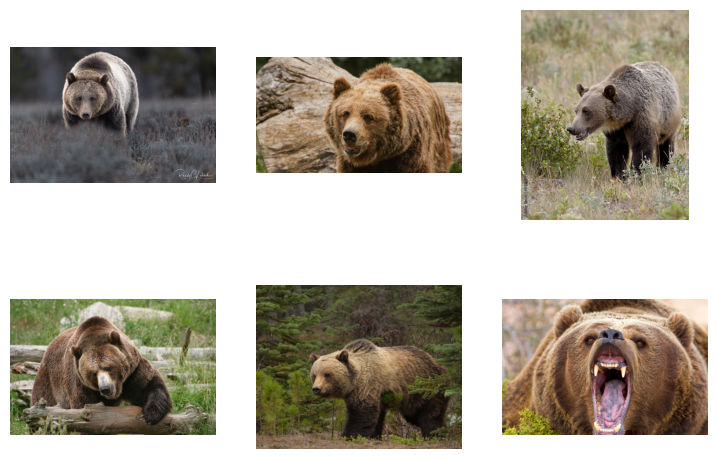

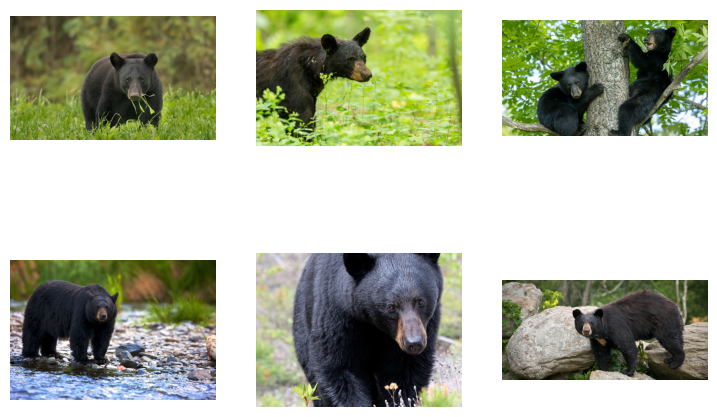

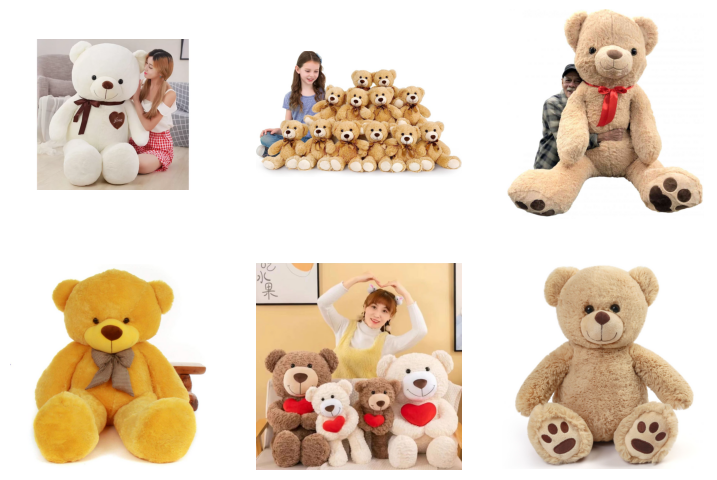

In [ ]:
from fastai.vision.all import *

for cls in classes:
    print(f"\n{cls.upper()}")

    files = get_image_files(path / cls)[:6]
    imgs = [PILImage.create(f) for f in files]

    show_images(imgs, nrows=2, ncols=3, figsize=(9, 6))

In [ ]:
dls = ImageDataLoaders.from_folder(
    path,
    train=".",
    valid_pct=0.2,
    seed=15,
    item_tfms=Resize(224),
    bs=8
)

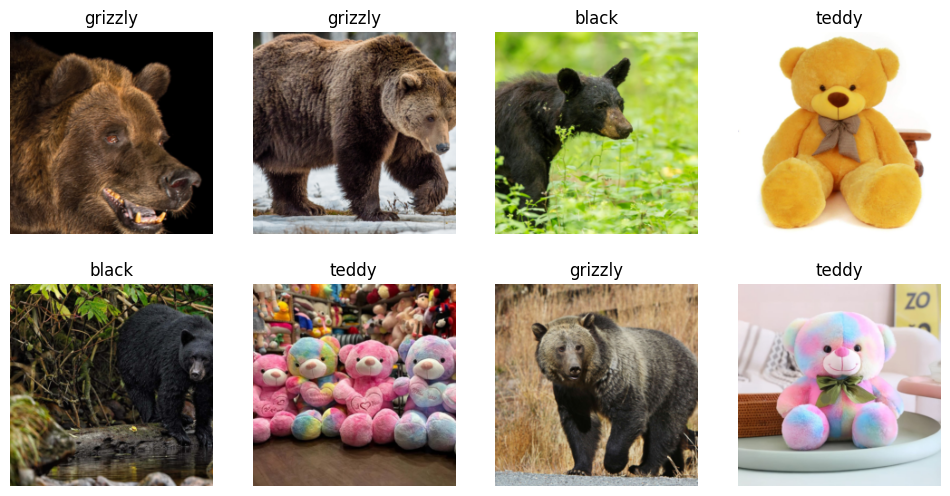

In [ ]:
dls.show_batch(max_n=9)

In [ ]:
learn = vision_learner(
    dls,
    resnet18,
    metrics=error_rate
)
learn.fine_tune(3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 101MB/s] 


epoch,train_loss,valid_loss,error_rate,time
0,1.384394,0.054756,0.000000,00:08


epoch,train_loss,valid_loss,error_rate,time
0,0.461702,0.013092,0.000000,00:03
1,0.304531,0.003439,0.000000,00:03
2,0.193157,0.002440,0.000000,00:04
